# Лабораторная 2 (CPU-вариант): декодерный трансформер на `Tiny Shakespeare`

Цель работы: перенести механизм авторегрессионного предсказания следующего токена
с детерминированной синтетики на реальный текстовый корпус в обязательном базовом режиме `CPU-friendly`.

## Что нужно знать до старта
- Уже пройдена `04/LR01` и понятны `padding_mask` и `causal_mask`.
- Есть ориентир по метрикам: `perplexity`, `baseline_perplexity`, `mean_match_ratio`.
- Важно не менять фиксированные настройки постановки и не сдвигать gate-критерии.

## Интуиция задачи без формул
Мы учим модель продолжать текст по одному токену: на каждом шаге она видит только прошлое и текущий контекст.
Если причинная маска работает корректно, модель не может "подсматривать" будущее, а качество растёт за счёт лучшего языкового паттерна, а не утечки.

## Контракт данных (быстрый ориентир)
- `token_windows`: индексы токенов формы `(batch, context)`.
- `targets`: next-token цели формы `(batch, context)`.
- `padding_mask`: булева маска `(batch, context)` для исключения `PAD` в loss/metric.
- `causal_mask`: нижнетреугольная матрица `(context, context)` для запрета доступа в будущее.
- Итоговые проверки: `test_perplexity < baseline_perplexity` и generation gates по `success_count/mean_match_ratio`.



## Маршрут выполнения

Строгий порядок шагов:
1. `TODO 1`: загрузка корпуса и построение словаря.
2. `TODO 2`: окна фиксированной длины и индексное разбиение.
3. `TODO 3`: декодерный блок с причинной маской.
4. `TODO 4`: обучение, метрики и сравнение с частотным ориентиром.
5. `TODO 5`: детерминированная генерация по фиксированным подсказкам.
6. `TODO 6`: диагностика внимания без доступа в будущее.


In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "auto")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/<org>/<repo>.git",
)
NOTEBOOK_REQUIREMENTS = "themes/04-Autoregression/lab/requirements.txt"


def _detect_notebook_platform():
    """Определяет тип среды выполнения текущей тетради.

    Аргументы:
      Нет.

    Возвращает:
      Строка из множества `{'local', 'colab', 'kaggle'}`.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    """Проверяет, похож ли путь на корень учебного репозитория.

    Аргументы:
      path: Проверяемый путь.

    Возвращает:
      `True`, если обнаружены ключевые признаки корня репозитория.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    """Возвращает стандартный путь клонирования для облачной платформы.

    Аргументы:
      platform: Имя платформы (`'colab'` или `'kaggle'`).

    Возвращает:
      Абсолютный путь каталога репозитория.

    Исключения:
      ValueError: Если передано неподдерживаемое имя платформы.
    """
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    """Проверяет, остался ли в настройке шаблонный URL репозитория.

    Аргументы:
      repo_url: Проверяемый URL репозитория.

    Возвращает:
      `True`, если URL имеет вид шаблона-заглушки.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    """Ищет корень курса, поднимаясь от текущего каталога вверх.

    Аргументы:
      Нет.

    Возвращает:
      Объект `Path` корня репозитория или `None`, если путь не найден.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    """Обеспечивает доступность модуля `course_runtime` для текущей среды.

    Аргументы:
      runtime_mode: Режим запуска тетради.
      repo_url: URL репозитория курса для облачной автозагрузки.

    Возвращает:
      `None`.

    Исключения:
      ModuleNotFoundError: Если локальный запуск выполнен вне корректного корня репозитория.
      RuntimeError: Если в облаке отсутствует валидный URL репозитория или каталог повреждён.
      subprocess.CalledProcessError: Если команда `git clone` завершается с ошибкой.
    """
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


#_ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)

#from course_runtime import setup_notebook_runtime

#runtime_info = setup_notebook_runtime(
#    runtime_mode=RUNTIME_MODE,
#    course_repo_https_url=COURSE_REPO_HTTPS_URL,
#    notebook_requirements=NOTEBOOK_REQUIREMENTS,
#)
#runtime_info.as_dict()


## Константы CPU-варианта

Этот ноутбук фиксирует обязательный маршрут `CPU-friendly`.
Параметры подбираются так, чтобы лабораторную можно было воспроизводимо пройти на центральном процессоре.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

SEED = 17
PAD_ID = 0
CHECK_GEN_STEPS = 12
PROMPT_COUNT = 20

cfg = {
    'chars': 250_000,
    'context': 64,
    'stride': 3,
    'batch_size': 64,
    'embed_dim': 96,
    'num_heads': 4,
    'ff_dim': 192,
    'epochs': 3,
    'learning_rate': 2e-3,
    'gen_match_ratio': 0.20,
    'gen_threshold': 3,
    'gen_mean_threshold': 0.10,
}

plt.style.use('default')
keras.utils.set_random_seed(SEED)


## Математический ориентир

Мы оптимизируем токенную перекрёстную энтропию (cross-entropy), которая эквивалентна
среднему отрицательному лог-правдоподобию для next-token задачи.

Перплексия (perplexity) вычисляется как:

$$
\mathrm{PPL} = e^{\mathrm{loss}}
$$

Дополнительно в этой работе используется частотный базовый ориентир:
если модель не превосходит его по перплексии, перенос на реальный корпус считается недостаточным.


## TODO 1: загрузка корпуса и построение словаря


In [3]:
def load_tiny_shakespeare(profile_cfg):
    """Загружает корпус и строит детерминированное символьное кодирование.

    Аргументы:
      profile_cfg: Словарь параметров выбранного профиля.

    Возвращает:
      Кортеж `(text, encoded_ids, vocab, char_to_id, id_to_char)`.

    Исключения:
      ValueError: Если выбранный профиль задаёт слишком короткий фрагмент текста.
    """
    # TODO 1.1: Загрузите корпус Tiny Shakespeare через tf.keras.utils.get_file.
    path = tf.keras.utils.get_file(
        'shakespeare.txt',
        'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
    )
    
    with open(path, 'r') as f:
        full_text = f.read()

    # TODO 1.2: Возьмите детерминированный срез длины profile_cfg['chars'].
    text = full_text[:profile_cfg['chars']]
    # TODO 1.3: Постройте словарь ['<PAD>', ...] и кодирование в int32.
    unique_chars = sorted(list(set(text)))
    vocab = ['<PAD>'] + unique_chars  # PAD_ID = 0
    
    char_to_id = {ch: i for i, ch in enumerate(vocab)}
    id_to_char = {i: ch for i, ch in enumerate(vocab)}
    
    encoded_ids = np.array([char_to_id[ch] for ch in text], dtype=np.int32)
    
    return text, encoded_ids, vocab, char_to_id, id_to_char



# TODO 1.4: Вызовите load_tiny_shakespeare(cfg) и сохраните результаты в
# text, encoded_ids, vocab, char_to_id, id_to_char.
text, encoded_ids, vocab, char_to_id, id_to_char = load_tiny_shakespeare(cfg)



1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 5s 4us/step


In [4]:
# Мини-проверка после TODO 1
assert len(text) == cfg['chars'], 'Длина среза текста не совпадает с профилем.'
assert encoded_ids.dtype == np.int32, 'Кодирование должно быть int32.'
assert vocab[PAD_ID] == '<PAD>', 'Нулевой идентификатор должен быть зарезервирован под PAD.'

text_b, ids_b, _, _, _ = load_tiny_shakespeare(cfg)
assert np.array_equal(encoded_ids[:1000], ids_b[:1000]), 'Кодирование должно быть воспроизводимым.'

print('Режим выполнения: cpu_friendly')
print('Длина текста:', len(text))
print('Размер словаря:', len(vocab))


Режим выполнения: cpu_friendly
Длина текста: 250000
Размер словаря: 63


## TODO 2: окна фиксированной длины и разбиение


In [5]:
def build_windows(encoded_stream, context_len, stride):
    """Строит обучающие окна фиксированной длины.

    Аргументы:
      encoded_stream: Одномерный массив кодов символов.
      context_len: Длина входного контекста.
      stride: Шаг между соседними окнами.

    Возвращает:
      Кортеж `(X, Y, starts)`.

    Исключения:
      ValueError: Если поток слишком короткий для построения хотя бы одного окна.
    """
    # TODO 2.1: Постройте X и Y со сдвигом на один шаг.
    # TODO 2.2: Верните также массив стартовых индексов starts.
    windows = []
    targets = []
    starts = []
    
    max_start = len(encoded_stream) - context_len - 1
    
    for start in range(0, max_start + 1, stride):
        X = encoded_stream[start:start + context_len]
        Y = encoded_stream[start + 1:start + context_len + 1]
        windows.append(X)
        targets.append(Y)
        starts.append(start)
    
    return np.array(windows), np.array(targets), np.array(starts)


X_all, y_all, starts_all = build_windows(encoded_ids, cfg['context'], cfg['stride'])


# TODO 2.3: Выполните индексное разбиение X_all, y_all, starts_all на
# train/val/test без случайного перемешивания.
total = len(X_all)
train_split = int(0.8 * total)
val_split = int(0.9 * total)

X_train = X_all[:train_split]
y_train = y_all[:train_split]
starts_train = starts_all[:train_split]

X_val = X_all[train_split:val_split]
y_val = y_all[train_split:val_split]
starts_val = starts_all[train_split:val_split]

X_test = X_all[val_split:]
y_test = y_all[val_split:]
starts_test = starts_all[val_split:]




In [6]:
# Мини-проверка после TODO 2
assert X_train.shape[1] == cfg['context']
assert y_train.shape == X_train.shape
assert starts_train.ndim == 1

# Проверка сдвига внутри окон.
assert np.array_equal(X_train[0, 1:], y_train[0, :-1]), 'Сдвиг X/Y нарушен.'

print('Окон train/val/test:', len(X_train), len(X_val), len(X_test))


Окон train/val/test: 66649 8331 8332


## TODO 3: декодерный блок с причинной маской


In [7]:
def build_causal_mask(seq_len):
    """Строит нижнетреугольную причинную маску.

    Аргументы:
      seq_len: Длина последовательности.

    Возвращает:
      Булев тензор формы `(seq_len, seq_len)`.

    Исключения:
      tf.errors.InvalidArgumentError: Если `seq_len` не является положительным.
    """
    # TODO 3.1: Реализуйте построение нижнетреугольной маски. Используйте тензорную
    # проверку `tf.debugging.assert_positive`, чтобы код работал и в графовом режиме.
    tf.debugging.assert_positive(seq_len)
    mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return tf.cast(mask, tf.bool)


class TokenAndPositionEmbedding(layers.Layer):
    """Складывает токенные и позиционные векторы.

    Аргументы:
      maxlen: Максимальная длина контекста.
      vocab_size: Размер словаря.
      embed_dim: Размер скрытого представления.
      **kwargs: Дополнительные аргументы базового слоя.

    Возвращает:
      Экземпляр слоя встраивания.

    Исключения:
      ValueError: Если `embed_dim` меньше 1.
    """

    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        """Инициализирует слой токенного и позиционного встраивания.

        Аргументы:
          maxlen: Максимальная длина контекста.
          vocab_size: Размер словаря токенов.
          embed_dim: Размерность векторного представления.
          **kwargs: Дополнительные аргументы базового слоя Keras.

        Возвращает:
          None.

        Исключения:
          ValueError: Если `embed_dim` меньше 1.
        """
        super().__init__(**kwargs)
        if embed_dim < 1:
            raise ValueError('embed_dim должен быть положительным.')
        self.token_embedding = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.position_embedding = layers.Embedding(maxlen, embed_dim)

    def call(self, inputs):
        """Суммирует токенные и позиционные векторы.

        Аргументы:
          inputs: Матрица идентификаторов формы `(batch, time)`.

        Возвращает:
          Тензор формы `(batch, time, embed_dim)`.

        Исключения:
          NotImplementedError: Пока шаг `TODO 3` не реализован.
        """
        # TODO 3.2: Реализуйте сложение token embedding и position embedding.
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        token_emb = self.token_embedding(inputs)
        pos_emb = self.position_embedding(positions)
        return token_emb + pos_emb

    def compute_mask(self, inputs, mask=None):
        """Пробрасывает маску непустых токенов.

        Аргументы:
          inputs: Матрица токенов.
          mask: Входная маска.

        Возвращает:
          Булева маска формы `(batch, time)`.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return self.token_embedding.compute_mask(inputs)


class CausalDecoderBlock(layers.Layer):
    """Минимальный декодерный блок с причинной маской.

    Аргументы:
      embed_dim: Размер скрытого представления.
      num_heads: Число голов внимания.
      ff_dim: Размер скрытого слоя позиционно-независимой сети.
      rate: Доля прореживания.
      **kwargs: Дополнительные аргументы базового слоя.

    Возвращает:
      Экземпляр декодерного блока.

    Исключения:
      ValueError: Если `embed_dim` не делится на `num_heads`.
    """

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        """Создаёт внутренние слои декодерного блока.

        Аргументы:
          embed_dim: Размерность входных признаков.
          num_heads: Число голов внимания.
          ff_dim: Размер скрытого слоя позициионно-независимой сети.
          rate: Доля выключаемых нейронов в прореживании.
          **kwargs: Дополнительные аргументы базового слоя Keras.

        Возвращает:
          None.

        Исключения:
          ValueError: Если `embed_dim` не делится на `num_heads`.
        """
        super().__init__(**kwargs)
        if embed_dim % num_heads != 0:
            raise ValueError('embed_dim должен делиться на num_heads без остатка.')
        self.self_attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=rate,
        )
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation='relu'),
                layers.Dense(embed_dim),
            ]
        )
        self.norm_1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm_2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout_1 = layers.Dropout(rate)
        self.dropout_2 = layers.Dropout(rate)

    def call(self, inputs, padding_mask=None, training=None, return_attention_scores=False):
        """Прогоняет вход через маскированное самовнимание и FFN.

        Аргументы:
          inputs: Тензор формы `(batch, time, embed_dim)`.
          padding_mask: Булева маска формы `(batch, time)`.
          training: Признак режима обучения.
          return_attention_scores: Нужно ли вернуть веса внимания.

        Возвращает:
          Либо выходной тензор, либо кортеж `(выход, attention_scores)`.

        Исключения:
          NotImplementedError: Пока шаг `TODO 3` не реализован.
        """
        # TODO 3.3: Реализуйте causal mask + padding mask и прямой проход блока.
        seq_len = tf.shape(inputs)[1]
        causal_mask = build_causal_mask(seq_len)
        
        if padding_mask is not None:
            padding_mask = tf.cast(padding_mask, tf.bool)
            padding_mask_expanded = padding_mask[:, tf.newaxis, :]
            combined_mask = causal_mask & padding_mask_expanded
        else:
            combined_mask = causal_mask
        
        attn_output, attn_scores = self.self_attention(
            query=inputs, value=inputs, key=inputs,
            attention_mask=combined_mask,
            return_attention_scores=True,
            training=training
        )
        
        out1 = self.norm_1(inputs + self.dropout_1(attn_output, training=training))
        ffn_output = self.ffn(out1)
        out2 = self.norm_2(out1 + self.dropout_2(ffn_output, training=training))
        
        if return_attention_scores:
            return out2, attn_scores
        return out2

    def compute_mask(self, inputs, mask=None):
        """Отключает автоматическое пробрасывание маски в выход блока.

        Аргументы:
          inputs: Входной тензор признаков.
          mask: Маска, пришедшая от предыдущего слоя.

        Возвращает:
          `None`, чтобы маскирование контролировалось явно в функции потерь.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return None


def masked_sparse_crossentropy(y_true, y_pred):
    """Считает перекрёстную энтропию по непустым позициям.

    Аргументы:
      y_true: Истинные токены.
      y_pred: Предсказанные распределения.

    Возвращает:
      Среднее значение функции потерь.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    per_token = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(per_token * mask) / tf.reduce_sum(mask)


def masked_token_accuracy(y_true, y_pred):
    """Считает токенную точность по непустым позициям.

    Аргументы:
      y_true: Истинные токены.
      y_pred: Предсказанные распределения.

    Возвращает:
      Доля верных токенов.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    pred = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)
    correct = tf.cast(tf.equal(y_true, pred), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(correct * mask) / tf.reduce_sum(mask)


def perplexity_from_loss(loss_value):
    """Преобразует значение функции потерь в перплексию.

    Аргументы:
      loss_value: Средняя перекрёстная энтропия.

    Возвращает:
      Значение перплексии.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return float(np.exp(loss_value))


def frequency_baseline_perplexity(y_train_data, y_test_data, vocab_size, pad_id=PAD_ID):
    """Считает частотный базовый ориентир перплексии.

    Аргументы:
      y_train_data: Целевые токены обучающей выборки.
      y_test_data: Целевые токены тестовой выборки.
      vocab_size: Размер словаря.
      pad_id: Идентификатор дополнения.

    Возвращает:
      Значение базовой перплексии.

    Исключения:
      ValueError: Если в данных нет полезных токенов.
    """
    train_tokens = y_train_data[y_train_data != pad_id].reshape(-1)
    test_tokens = y_test_data[y_test_data != pad_id].reshape(-1)
    if len(train_tokens) == 0 or len(test_tokens) == 0:
        raise ValueError('Для базового ориентира нужны непустые токены.')

    counts = np.bincount(train_tokens, minlength=vocab_size).astype(np.float64)
    probs = counts / counts.sum()
    probs = np.maximum(probs, 1e-12)

    nll = -np.mean(np.log(probs[test_tokens]))
    return float(np.exp(nll))


## TODO 4: сборка и обучение модели


In [9]:
# TODO 4.1: Соберите модель decoder-only с TokenAndPositionEmbedding и CausalDecoderBlock.
context_len = cfg['context']
vocab_size = len(vocab)

inputs = keras.Input(shape=(context_len,), dtype='int32', name='tokens')

# Padding mask через Lambda
padding_mask = layers.Lambda(
    lambda x: tf.cast(tf.not_equal(x, PAD_ID), tf.bool),
    name='padding_mask'
)(inputs)

embedding_layer = TokenAndPositionEmbedding(context_len, vocab_size, cfg['embed_dim'])
x = embedding_layer(inputs)

decoder_block = CausalDecoderBlock(cfg['embed_dim'], cfg['num_heads'], cfg['ff_dim'])
x, attention_scores = decoder_block(x, padding_mask=padding_mask, return_attention_scores=True)

outputs = layers.Dense(vocab_size, activation='softmax')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# TODO 4.2: Скомпилируйте модель с masked_sparse_crossentropy и masked_token_accuracy.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg['learning_rate']),
    loss=masked_sparse_crossentropy,
    metrics=[masked_token_accuracy]
)

model.summary()

# TODO 4.3: Обучите модель на train_ds и val_ds в детерминированном порядке.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=cfg['batch_size'],
    epochs=cfg['epochs'],
    verbose=1
)

# TODO 4.4: Посчитайте test_loss, test_accuracy, test_perplexity и baseline_perplexity.
test_loss, test_token_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_perplexity = perplexity_from_loss(test_loss)
baseline_perplexity = frequency_baseline_perplexity(y_train, y_test, vocab_size)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 64)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 64, 96)    │     12,192 │ tokens[0][0]      │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 64)        │          0 │ tokens[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_decoder_blo… │ [(None, 64, 96),  │     74,784 │ token_and_positi… │
│ (CausalDecoderBloc… │ (None, 4, 64,     │            │ padding_mask[0][… │
│                     │ 64)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64, 63)    │      6,111 │ causal_decoder_b… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 93,087 (363.62 KB)

 Trainable params: 93,087 (363.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 53s 48ms/step - loss: 2.0623 - masked_token_accuracy: 0.3898 - val_loss: 1.9569 - val_masked_token_accuracy: 0.4492
Epoch 2/3
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 50s 48ms/step - loss: 1.7402 - masked_token_accuracy: 0.4755 - val_loss: 1.8904 - val_masked_token_accuracy: 0.4657
Epoch 3/3
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 50s 48ms/step - loss: 1.6828 - masked_token_accuracy: 0.4897 - val_loss: 1.8667 - val_masked_token_accuracy: 0.4770


test_loss            : 1.8113
test_token_accuracy  : 0.4885
test_perplexity      : 6.1183
baseline_perplexity  : 28.6445


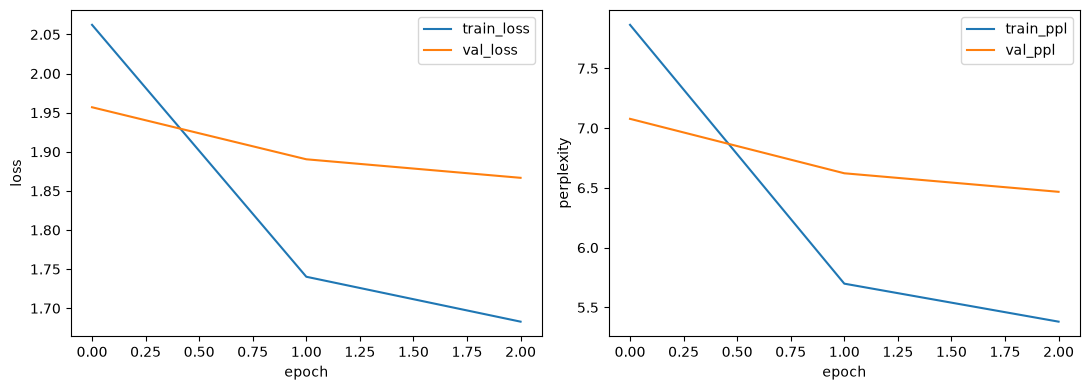

In [10]:
# Графики и контроль после TODO 4
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.subplot(1, 2, 2)
train_ppl = [perplexity_from_loss(v) for v in history.history['loss']]
val_ppl = [perplexity_from_loss(v) for v in history.history['val_loss']]
plt.plot(train_ppl, label='train_ppl')
plt.plot(val_ppl, label='val_ppl')
plt.xlabel('epoch')
plt.ylabel('perplexity')
plt.legend()
plt.tight_layout()

print(f"test_loss            : {test_loss:.4f}")
print(f"test_token_accuracy  : {test_token_accuracy:.4f}")
print(f"test_perplexity      : {test_perplexity:.4f}")
print(f"baseline_perplexity  : {baseline_perplexity:.4f}")

assert test_perplexity < baseline_perplexity, 'Модель должна превосходить частотный ориентир.'


## TODO 5: детерминированная генерация по фиксированным подсказкам


In [12]:
def ids_to_text(token_ids, id_to_char_map):
    """Преобразует идентификаторы в строку.

    Аргументы:
      token_ids: Последовательность идентификаторов.
      id_to_char_map: Отображение id -> символ.

    Возвращает:
      Строка символов.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return ''.join(id_to_char_map.get(int(token), '') for token in token_ids if int(token) != PAD_ID)


def generate_greedy(model, prompt_ids, steps, context_len):
    """Генерирует продолжение в режиме argmax.

    Аргументы:
      model: Обученная модель.
      prompt_ids: Начальная последовательность идентификаторов.
      steps: Число новых токенов.
      context_len: Длина модельного контекста.

    Возвращает:
      Список токенов продолжения длины не больше `steps`.

    Исключения:
      ValueError: Если подсказка пуста.
    """
    # TODO 5.1: Реализуйте генерацию argmax без случайной выборки.
    if len(prompt_ids) == 0:
        raise ValueError('Подсказка не может быть пустой.')
    
    generated = list(prompt_ids)
    
    for step in range(steps):
        # Формируем вход: последние context_len токенов или дополняем PAD
        if len(generated) >= context_len:
            input_ids = generated[-context_len:]
        else:
            input_ids = generated + [PAD_ID] * (context_len - len(generated))
        
        input_tensor = np.array([input_ids], dtype=np.int32)
        
        probs = model.predict(input_tensor, verbose=0)
        # Берём предсказание для ПОСЛЕДНЕЙ позиции (индекс len(input_ids) - 1)
        next_token = np.argmax(probs[0, len(input_ids) - 1])
        
        if next_token == PAD_ID:
            break
        generated.append(next_token)
    
    return generated



def build_prompt_targets(encoded_stream, start_indices, context_len, continuation_len, n_prompts):
    """Готовит фиксированные подсказки и эталонные продолжения из тестового фрагмента.

    Аргументы:
      encoded_stream: Полный поток кодов корпуса.
      start_indices: Стартовые индексы окон тестовой части.
      context_len: Длина контекста модели.
      continuation_len: Длина целевого продолжения.
      n_prompts: Количество подсказок.

    Возвращает:
      Список пар `(prompt_ids, target_ids)`.

    Исключения:
      ValueError: Если тестовых окон недостаточно.
    """
    valid_starts = [
        int(start) for start in start_indices
        if int(start) + context_len + continuation_len <= len(encoded_stream)
    ]
    if len(valid_starts) < n_prompts:
        raise ValueError('Недостаточно тестовых окон для фиксированного набора подсказок.')

    selected = np.linspace(0, len(valid_starts) - 1, n_prompts, dtype=int)
    pairs = []
    for idx in selected:
        start = valid_starts[int(idx)]
        prompt = encoded_stream[start:start + context_len]
        target = encoded_stream[start + context_len:start + context_len + continuation_len]
        pairs.append((prompt.tolist(), target.tolist()))
    return pairs


# TODO 5.2: Постройте fixed_pairs через build_prompt_targets(...), затем
# посчитайте `success_count` и `mean_match_ratio` по фиксированным подсказкам.
# Подсказка: успех по одной подсказке фиксируйте, если
# `match_ratio >= cfg['gen_match_ratio']`.
# Итоговые пороги: `success_count >= cfg['gen_threshold']` и
# `mean_match_ratio >= cfg['gen_mean_threshold']`.
fixed_pairs = build_prompt_targets(encoded_ids, starts_test, cfg['context'], CHECK_GEN_STEPS, PROMPT_COUNT)

success_count = 0
match_ratios = []

for prompt, target in fixed_pairs:
    generated_full = generate_greedy(model, prompt, CHECK_GEN_STEPS, cfg['context'])
    generated = generated_full[len(prompt):]
    
    # Сравниваем с эталоном
    matches = sum(1 for g, t in zip(generated, target) if g == t)
    match_ratio = matches / len(target) if len(target) > 0 else 0
    match_ratios.append(match_ratio)
    
    if match_ratio >= cfg['gen_match_ratio']:
        success_count += 1

mean_match_ratio = np.mean(match_ratios)

print(f"success_count      : {success_count}/{PROMPT_COUNT} (порог: {cfg['gen_threshold']})")
print(f"mean_match_ratio   : {mean_match_ratio:.4f} (порог: {cfg['gen_mean_threshold']})")

assert success_count >= cfg['gen_threshold'], f'Недостаточно успешных генераций: {success_count}'
assert mean_match_ratio >= cfg['gen_mean_threshold'], f'Среднее совпадение слишком низкое: {mean_match_ratio:.4f}'

sample_idx = 0
sample_prompt = fixed_pairs[sample_idx][0]
sample_target = fixed_pairs[sample_idx][1]
sample_generated_full = generate_greedy(model, sample_prompt, CHECK_GEN_STEPS, cfg['context'])
sample_generated = sample_generated_full[len(sample_prompt):]

print("\n=== ПРИМЕР ГЕНЕРАЦИИ ===")
print(f"Подсказка: {ids_to_text(sample_prompt, id_to_char)}")
print(f"Эталон: {ids_to_text(sample_target, id_to_char)}")
print(f"Сгенерировано: {ids_to_text(sample_generated, id_to_char)}")


success_count      : 6/20 (порог: 3)
mean_match_ratio   : 0.1750 (порог: 0.1)

=== ПРИМЕР ГЕНЕРАЦИИ ===
Подсказка: tuary in seizing him.
The benefit thereof is always granted
To t
Эталон: hose whose d
Сгенерировано: he people to


## TODO 6: диагностика внимания



=== ДИАГНОСТИКА ВНИМАНИЯ ===
Активная длина: 64
Доля внимания к будущим позициям: 0.000000
Причинная маска работает корректно!


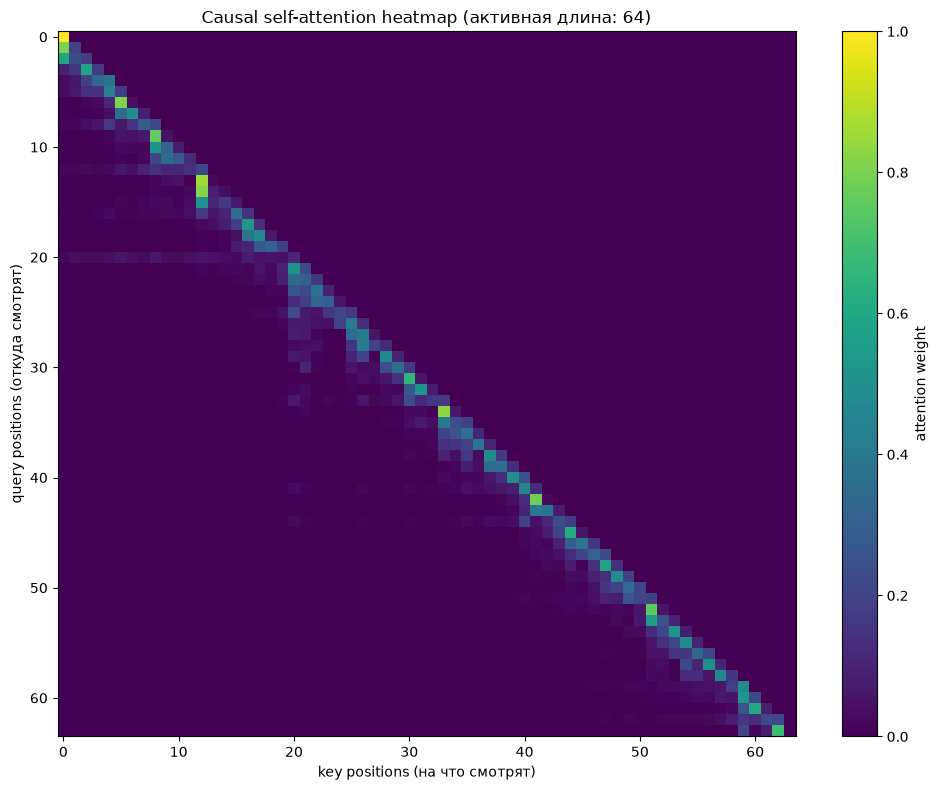

In [13]:
# TODO 6.1: Постройте trace-модель, которая возвращает attention_scores из decoder_layer.
trace_inputs = keras.Input(shape=(context_len,), dtype='int32', name='trace_tokens')
trace_padding_mask = layers.Lambda(
    lambda x: tf.cast(tf.not_equal(x, PAD_ID), tf.bool),
    name='trace_padding_mask'
)(trace_inputs)
trace_embeddings = embedding_layer(trace_inputs)
_, trace_attention = decoder_block(trace_embeddings, padding_mask=trace_padding_mask, return_attention_scores=True)

trace_model = keras.Model(inputs=trace_inputs, outputs=trace_attention)
# TODO 6.2: Усредните веса внимания по головам и вычислите отношение массы в будущем.
sample_tokens = X_test[0:1]
sample_attention = trace_model.predict(sample_tokens, verbose=0)

# Усредняем по головам
mean_attention = sample_attention[0].mean(axis=0)

# Находим активную длину
active_len = np.argmax(sample_tokens[0] == PAD_ID)
if active_len == 0:
    active_len = context_len

mean_attention = mean_attention[:active_len, :active_len]
# TODO 6.3: Проверьте, что отношение массы в будущем меньше 1e-4.
future_mask = np.triu(np.ones((active_len, active_len)), k=1).astype(bool)
future_attention = mean_attention[future_mask].sum()
total_attention = mean_attention.sum()
future_ratio = future_attention / total_attention

print(f"\n=== ДИАГНОСТИКА ВНИМАНИЯ ===")
print(f"Активная длина: {active_len}")
print(f"Доля внимания к будущим позициям: {future_ratio:.6f}")

assert future_ratio < 1e-4, "Обнаружен доступ к будущим позициям!"
print("Причинная маска работает корректно!")

# Визуализация heatmap
plt.figure(figsize=(10, 8))
plt.imshow(mean_attention, cmap='viridis', aspect='auto')
plt.colorbar(label='attention weight')
plt.xlabel('key positions (на что смотрят)')
plt.ylabel('query positions (откуда смотрят)')
plt.title(f'Causal self-attention heatmap (активная длина: {active_len})')
plt.tight_layout()
plt.show()



## Чек-лист перед завершением `ЛР02` (CPU-вариант)

1. Все `TODO` закрыты.
2. `test_perplexity < baseline_perplexity`.
3. Порог генерации достигнут: `success_count >= cfg['gen_threshold']`.
4. Дополнительно достигнут средний порог: `mean_match_ratio >= cfg['gen_mean_threshold']`.
5. Диагностика внимания подтверждает отсутствие доступа в будущее.
6. Результаты этого ноутбука сохранены для сравнения с `GPU`-вариантом.
